# Analysis and Forecasting of Financial Time Series
## Global Spillovers between US and Indian Equity Markets

---

**Dataset:** Daily observations from 2007 — S&P 500, NIFTY 50, USD/INR, VIX  
**Period:** September 2007 to Today  
**Frequency:** Daily  

---

## The Fundamental Framework

Every decision in this project is guided by one principle:

> **Data = Signal + Noise**

Our objective is to sequentially extract all signal from the data
until only pure white noise remains. White noise is defined as a 
series with no predictable structure in any statistical moment:

- **First moment (mean):** E[ε(t)] = 0, no autocorrelation in residuals
- **Second moment (variance):** E[ε²(t)] = σ², no autocorrelation in squared residuals

We extract signal in two sequential stages:

| Stage | Tool | Extracts | Checks |
|-------|------|----------|--------|
| 1 | VAR Model | Mean structure (Signal 1) | ACF of residuals flat? |
| 2 | GARCH Model | Variance structure (Signal 2) | ACF of squared residuals flat? |

Only when both checks pass do we conclude all signal has been extracted.

---

## Research Questions

1. Do the US and Indian equity markets share a long-run equilibrium?
2. Does the US market transmit shocks to India in the short run?
3. Does global fear (VIX) drive both markets simultaneously?
4. How persistent is volatility after a market shock?

In [24]:
import sys
import os
sys.path.append('..')  # Add project root to path

In [25]:
# Fetch Data

from src.fetch_data import fetch_data  

data = fetch_data()

In [26]:
data.head()

,SP500,NIFTY,USDINR,VIX
Date,,,,
2007-09-17,1476.650024,4494.649902,40.376999,26.480000
2007-09-18,1519.780029,4546.200195,40.216999,20.350000
2007-09-19,1529.030029,4732.350098,40.033001,20.030001
2007-09-20,1518.750000,4747.549805,39.615002,20.450001
2007-09-21,1525.750000,4837.549805,39.770000,19.000000


## Setup — Libraries and Dependencies

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns


from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen


from arch import arch_model

In [28]:
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

## Data

We use daily closing prices for four variables over the period 2007–2024:

| Variable |  Represents |
|----------| ------------|
| SP500 | US equity market — benchmark index |
| NIFTY | Indian equity market — benchmark index |
| USDINR | Exchange rate — rupee value vs dollar |
| VIX | CBOE Volatility Index — global fear gauge |

Price levels are retained for cointegration analysis. Log returns are
computed via first differences of log prices for all subsequent modeling.

In [29]:
import sys
import os
sys.path.append('..')  # Add project root to path

In [30]:
from src.fetch_data import *

data = fetch_data()

print(f"Observations : {data.shape[0]}")
print(f"Period       : {data.index.min().date()} to {data.index.max().date()}")

Observations : 4100
Period       : 2007-09-17 to 2024-12-30


In [31]:
print(f"\nMissing values:\n{data.isnull().sum()}")


Missing values:
SP500     0
NIFTY     0
USDINR    0
VIX       0
dtype: int64


In [32]:
data.head()

,SP500,NIFTY,USDINR,VIX
Date,,,,
2007-09-17,1476.650024,4494.649902,40.376999,26.480000
2007-09-18,1519.780029,4546.200195,40.216999,20.350000
2007-09-19,1529.030029,4732.350098,40.033001,20.030001
2007-09-20,1518.750000,4747.549805,39.615002,20.450001
2007-09-21,1525.750000,4837.549805,39.770000,19.000000


### Log Returns

Raw prices are non-stationary so models break. Simple returns work but log returns have better mathematical properties for financial modeling — additivity, symmetry, and no lower bound constraint."

In [33]:
# –– Compute log returns ––––––––––––––––––––––––––

returns = np.log(data).diff().dropna()

print(f"Observations : {returns.shape[0]}")

Observations : 4099


In [34]:
print(f"\nSummary Statistics:")
returns.describe().round(4)


Summary Statistics:


,SP500,NIFTY,USDINR,VIX
count,4099.0000,4099.0000,4099.0000,4099.0000
mean,0.0003,0.0004,0.0002,-0.0001
std,0.0130,0.0135,0.0052,0.0791
min,-0.1277,-0.1523,-0.0610,-0.3831
25%,-0.0045,-0.0054,-0.0022,-0.0440
50%,0.0007,0.0007,0.0000,-0.0064
75%,0.0061,0.0068,0.0024,0.0358
max,0.1096,0.1633,0.0610,0.7682


#### Summary Statistics — Interpretation

All four return series have means approximately zero, consistent with
weak stationarity in the first moment. A few observations worth noting:

- **VIX** has the highest standard deviation (0.079) — nearly 6x that
  of equity returns, reflecting its nature as a fear index that spikes
  sharply during crises
- **Negative skew** is expected in equity returns — confirmed by the
  min values being larger in magnitude than the max for SP500 and NIFTY
- **VIX** shows positive skew — fear spikes up sharply but dissipates
  slowly, consistent with asymmetric volatility behavior
- All series have means close to zero, justifying the use of log returns
  for subsequent modeling

----

## Exploratory Data Analysis

### Price Levels and Returns

We first visualize price levels and log returns to identify broad
structural features — trends, volatility clustering, and crisis periods.

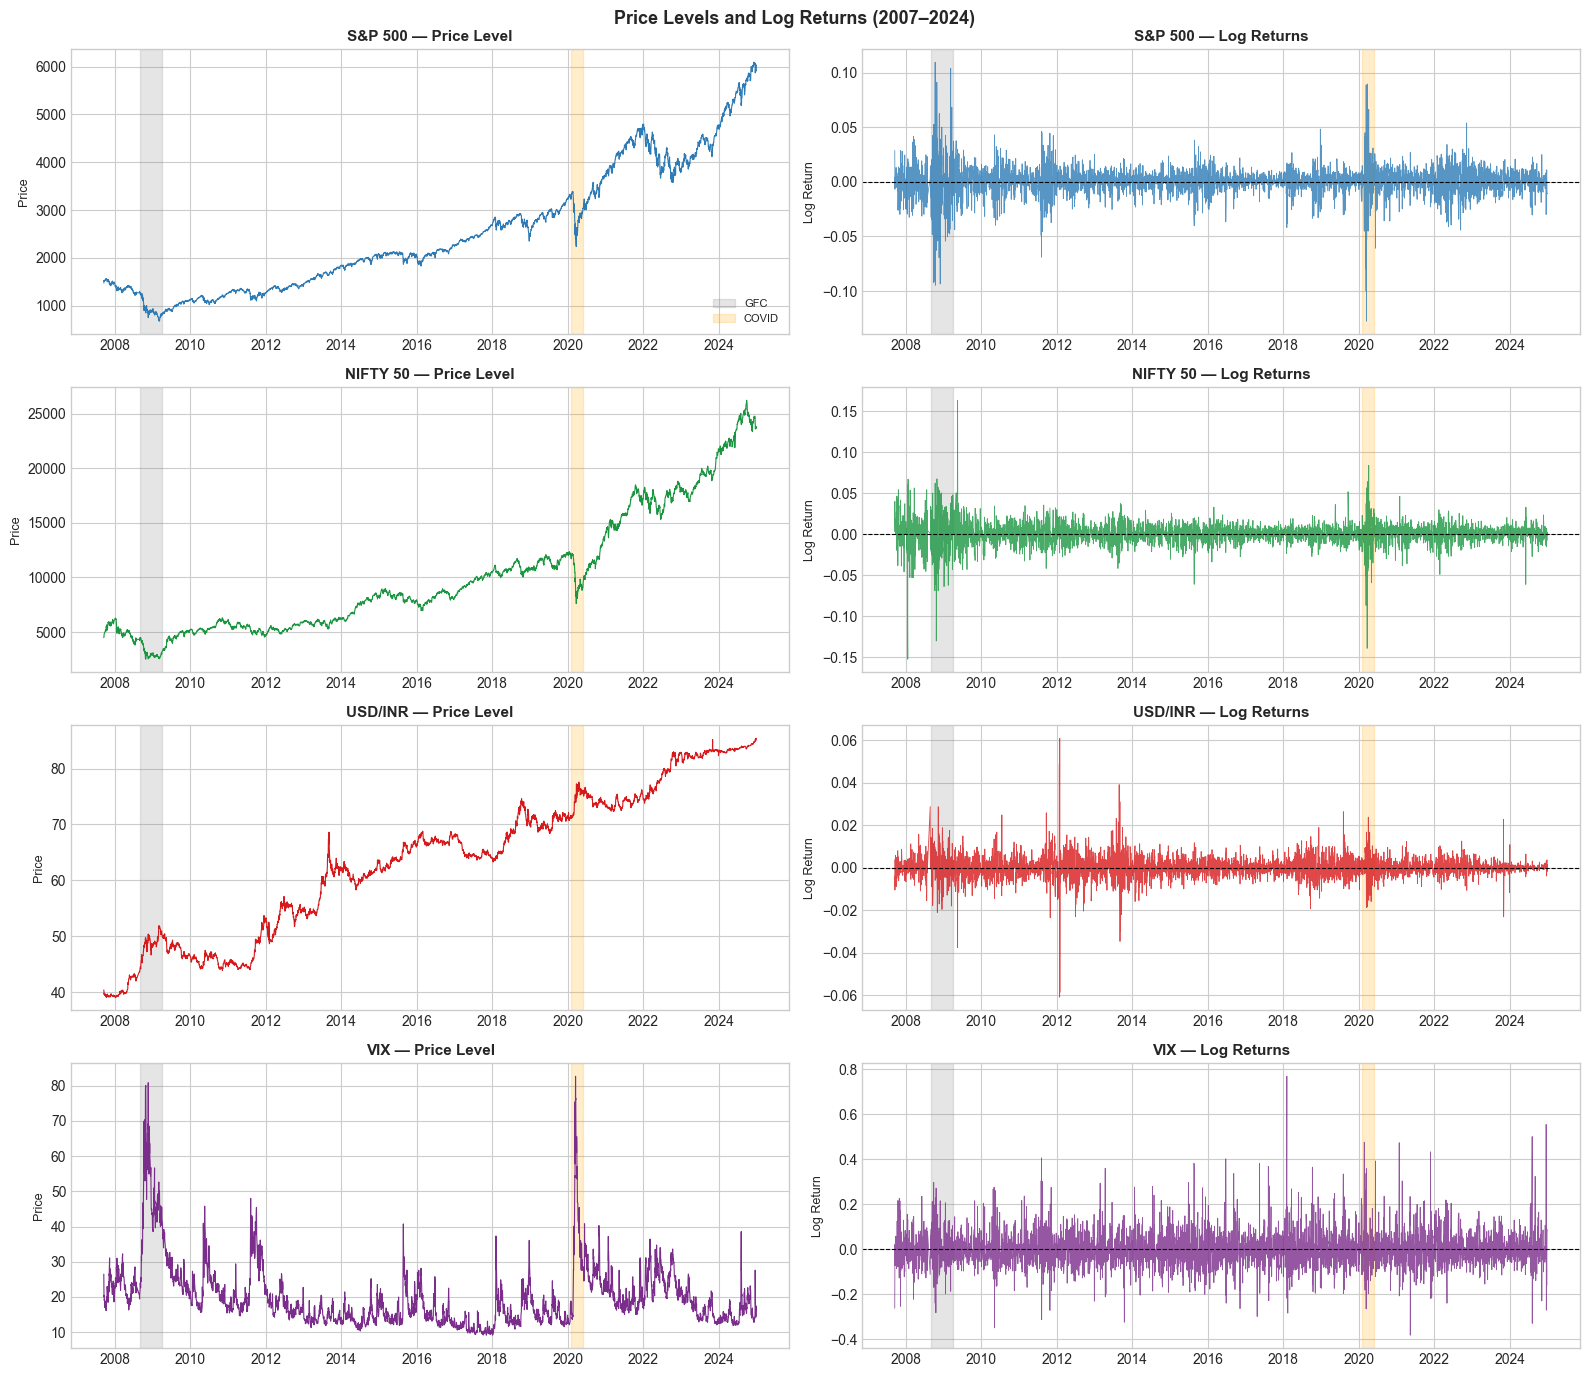

In [35]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=False)

series_info = [
    ("SP500",  "#2c7bb6", "S&P 500"),
    ("NIFTY",  "#1a9641", "NIFTY 50"),
    ("USDINR", "#d7191c", "USD/INR"),
    ("VIX",    "#7b2d8b", "VIX"),
]

crises = [
    (pd.Timestamp("2008-09-01"), pd.Timestamp("2009-03-31"), "gray",   "GFC"),
    (pd.Timestamp("2020-02-01"), pd.Timestamp("2020-05-31"), "orange", "COVID"),
]

for i, (col, color, title) in enumerate(series_info):
    # Price level
    ax1 = axes[i, 0]
    ax1.plot(data.index, data[col], color=color, linewidth=0.8)
    ax1.set_title(f"{title} — Price Level", fontsize=11, fontweight='bold')
    ax1.set_ylabel("Price", fontsize=9)
    for start, end, c, label in crises:
        ax1.axvspan(start, end, color=c, alpha=0.2, label=label)
    if i == 0:
        ax1.legend(fontsize=8)

    # Log returns
    ax2 = axes[i, 1]
    ax2.plot(returns.index, returns[col], color=color, linewidth=0.6, alpha=0.8)
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax2.set_title(f"{title} — Log Returns", fontsize=11, fontweight='bold')
    ax2.set_ylabel("Log Return", fontsize=9)
    for start, end, c, label in crises:
        ax2.axvspan(start, end, color=c, alpha=0.2)

plt.suptitle("Price Levels and Log Returns (2007–2024)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Price Levels and Returns — Observations

**Price levels** confirm non-stationarity across all four series —
SP500 and NIFTY trend upward persistently, USD/INR depreciates
steadily, and VIX exhibits mean-reverting spikes without a trend.

**Log returns** oscillate around zero for all series, with two
immediate observations:

- **Volatility clustering** is clearly visible — calm periods
  (2013–2019) are followed by turbulent bursts during GFC and COVID.
  This alone motivates GARCH modeling for the variance equation.

- **Synchronized spikes** — SP500, NIFTY and VIX all show large
  simultaneous movements during GFC (2008) and COVID (2020),
  suggesting co-movement during crisis periods. Whether this
  reflects direct transmission or a common global risk factor
  (VIX) is the central question this project addresses.

- **VIX returns** are notably more volatile than equity returns,
  with extreme spikes reaching +75% in a single day during COVID —
  consistent with the fear index nature of the series.

- **USD/INR** shows relatively subdued volatility compared to
  equities, with occasional sharp spikes likely reflecting RBI
  intervention episodes.

----

## Stage 1 — Stationarity Testing

Before modeling, we formally test whether the return series are
stationary using two complementary tests:

- **ADF (Augmented Dickey-Fuller):** H0: series has a unit root
- **KPSS (Kwiatkowski-Phillips-Schmidt-Shin):** H0: series is stationary

Running both provides a cross-check — if both agree the result is
unambiguous. We test on both price levels and log returns to confirm
that the log difference transformation achieves stationarity.

In [36]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_tests(series, name):
    adf  = adfuller(series, autolag='AIC')
    kpss_stat = kpss(series, regression='c', nlags='auto')
    return {
        'Series'        : name,
        'ADF Stat'      : round(adf[0], 4),
        'ADF p-value'   : round(adf[1], 6),
        'ADF Result'    : 'Stationary' if adf[1] < 0.05 else 'Non-Stationary',
        'KPSS Stat'     : round(kpss_stat[0], 4),
        'KPSS p-value'  : round(kpss_stat[1], 6),
        'KPSS Result'   : 'Stationary' if kpss_stat[1] > 0.05 else 'Non-Stationary',
    }

cols = ['SP500', 'NIFTY', 'USDINR', 'VIX']

# ── Test price levels ──────────────────────────────────────────
print("=" * 75)
print("  ADF & KPSS — PRICE LEVELS")
print("=" * 75)
levels_results = pd.DataFrame([
    stationarity_tests(data[c], c) for c in cols
]).set_index('Series')
print(levels_results.to_string())

# ── Test log returns ───────────────────────────────────────────
print("\n" + "=" * 75)
print("  ADF & KPSS — LOG RETURNS")
print("=" * 75)
returns_results = pd.DataFrame([
    stationarity_tests(returns[c], c) for c in cols
]).set_index('Series')
print(returns_results.to_string())

  ADF & KPSS — PRICE LEVELS
        ADF Stat  ADF p-value      ADF Result  KPSS Stat  KPSS p-value     KPSS Result
Series                                                                                
SP500     1.6309     0.997947  Non-Stationary     9.2256          0.01  Non-Stationary
NIFTY     1.3238     0.996739  Non-Stationary     8.7282          0.01  Non-Stationary
USDINR   -0.9166     0.782467  Non-Stationary     9.6484          0.01  Non-Stationary
VIX      -5.0464     0.000018      Stationary     1.3183          0.01  Non-Stationary

  ADF & KPSS — LOG RETURNS
        ADF Stat  ADF p-value  ADF Result  KPSS Stat  KPSS p-value KPSS Result
Series                                                                        
SP500   -15.1043          0.0  Stationary     0.2111           0.1  Stationary
NIFTY   -12.1085          0.0  Stationary     0.0585           0.1  Stationary
USDINR  -20.2695          0.0  Stationary     0.0731           0.1  Stationary
VIX     -28.6935          0

#### Stationarity Test Results

**Price Levels:**
SP500, NIFTY and USD/INR are confirmed non-stationary by both tests —
consistent with trending and unit root behaviour expected in financial
price series. VIX is an exception — ADF rejects the unit root while
KPSS rejects stationarity, an ambiguous result reflecting VIX's
unique nature: it is bounded (cannot go negative, rarely exceeds 80)
and mean-reverting by construction, yet exhibits persistent spikes
that KPSS detects as non-constant variance.

**Log Returns:**
Both ADF and KPSS agree across all four series — log returns are
stationary. ADF statistics are large in magnitude (−15 to −28) and
p-values are effectively zero, with KPSS statistics well below
critical values. This confirms that the log difference transformation
successfully achieves stationarity, and returns are appropriate
for subsequent VAR modeling.

The contrast between levels and returns validates the standard
practice of modeling returns rather than prices in financial
time series analysis.

## Stage 2 — VAR Model (Mean Equation)

Following confirmation of stationarity in log returns, we fit a
Vector Autoregression (VAR) model as the mean equation. VAR extends
univariate autoregression to a system of equations where each
variable is modeled as a function of its own past values and the
past values of all other variables in the system:

$$r_t = c + \Phi_1 r_{t-1} + \Phi_2 r_{t-2} + ... + \Phi_p r_{t-p} + \varepsilon_t$$

where $r_t = [SP500, NIFTY, USDINR, VIX]'$ and $\varepsilon_t$ is
the vector of residuals we aim to reduce to white noise.

Lag length is selected using information criteria prior to estimation.

In [37]:
from statsmodels.tsa.api import VAR

var_model = VAR(returns[['SP500', 'NIFTY', 'USDINR', 'VIX']])
lag_selection = var_model.select_order(maxlags=15)

print("=" * 55)
print("  VAR LAG LENGTH SELECTION")
print("=" * 55)
print(lag_selection.summary())

  VAR LAG LENGTH SELECTION
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -33.80      -33.79   2.094e-15      -33.80
1       -34.05     -34.02*   1.635e-15      -34.04
2       -34.06      -34.01   1.613e-15     -34.04*
3       -34.07      -33.99   1.602e-15      -34.04
4       -34.07      -33.96   1.600e-15      -34.03
5       -34.07      -33.94   1.602e-15      -34.02
6       -34.07      -33.91   1.601e-15      -34.01
7       -34.07      -33.89   1.593e-15      -34.01
8       -34.07      -33.87   1.593e-15      -34.00
9       -34.07      -33.85   1.590e-15      -33.99
10      -34.08      -33.82   1.589e-15      -33.99
11      -34.08      -33.80   1.588e-15      -33.98
12      -34.08      -33.77   1.590e-15      -33.97
13      -34.08      -33.75   1.586e-15      -33.96
14      -34.07      -33.72   1.590e-15      -33.95
15     -34.08*      -33.71  1.575e-15*      -33.95
----

### Lag Length Selection

AIC and FPE select lag 15 while BIC selects lag 1 and HQIC lag 2.
The marginal improvement in AIC beyond lag 2 is negligible (−34.06
to −34.08), suggesting the additional lags add little explanatory
power. Given the penalty for overparameterization with daily data
and the economic interpretability of a short lag structure, we
select **lag 2** following BIC and HQIC consensus — the most
parsimonious specification consistent with the data.

In [38]:
var_result = var_model.fit(2)

print("=" * 55)
print("  VAR(2) — MODEL FIT")
print("=" * 55)
print(f"Lag order          : {var_result.k_ar}")
print(f"Observations       : {var_result.nobs}")
print(f"AIC                : {round(var_result.aic, 4)}")
print(f"BIC                : {round(var_result.bic, 4)}")
print(f"HQIC               : {round(var_result.hqic, 4)}")
print(f"Log Likelihood     : {round(var_result.llf, 4)}")

  VAR(2) — MODEL FIT
Lag order          : 2
Observations       : 4097
AIC                : -34.0621
BIC                : -34.0066
HQIC               : -34.0425
Log Likelihood     : 46558.6835


### VAR(2) Residual Diagnostics

We now examine VAR residuals to determine whether the mean equation
has been fully specified. Two questions:

1. **Are residuals mean-white-noise?** — ACF of residuals should show
   no significant autocorrelation at any lag (first moment clean)
2. **Is variance structure remaining?** — ACF of squared residuals
   should reveal any ARCH effects left unmodeled (second moment check)

If the first is satisfied but the second is not, the mean equation is
complete but a variance equation (GARCH) is required.

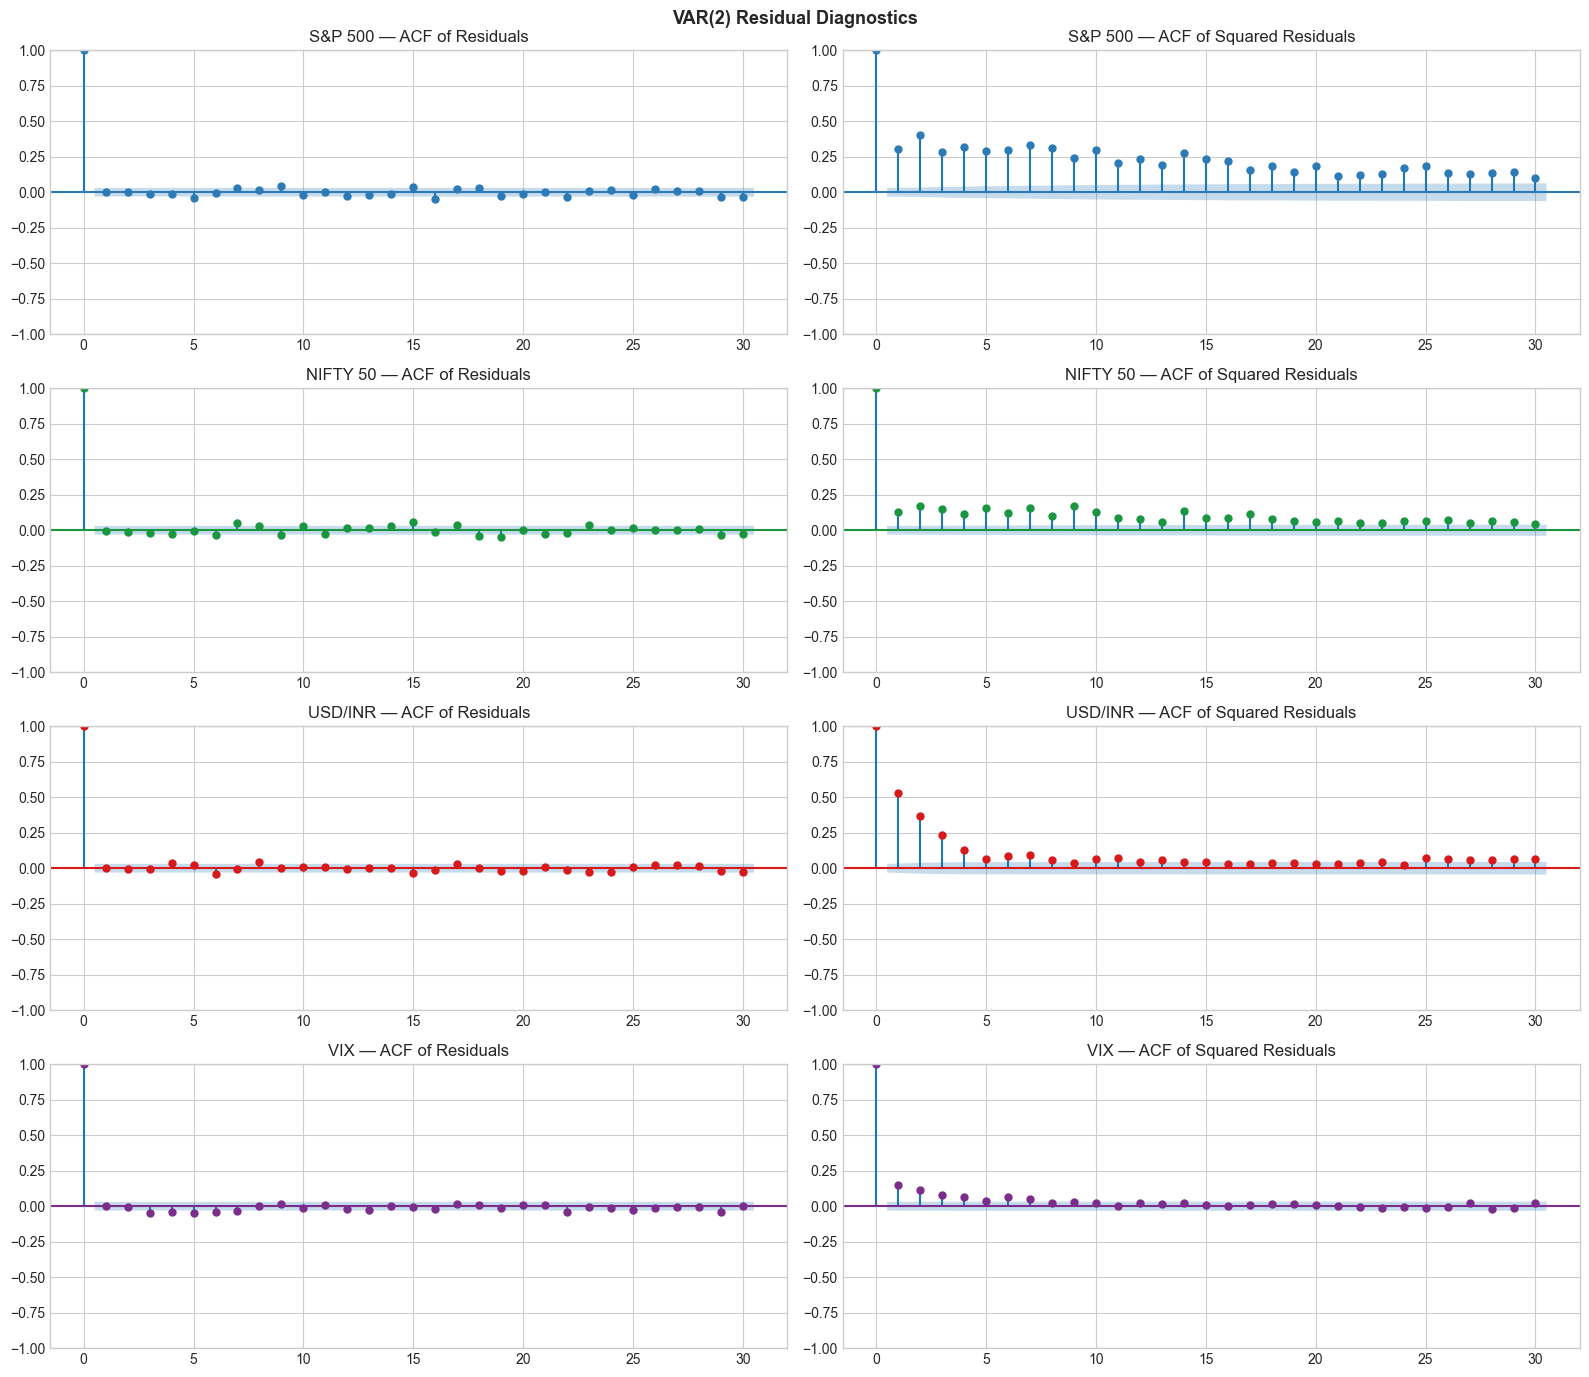

In [39]:
# ── Extract VAR residuals ──────────────────────────────────────
residuals = var_result.resid

fig, axes = plt.subplots(4, 2, figsize=(16, 14))

series_info = [
    ("SP500",  "#2c7bb6", "S&P 500"),
    ("NIFTY",  "#1a9641", "NIFTY 50"),
    ("USDINR", "#d7191c", "USD/INR"),
    ("VIX",    "#7b2d8b", "VIX"),
]

for i, (col, color, title) in enumerate(series_info):
    # ACF of residuals — first moment check
    plot_acf(residuals[col], lags=30, ax=axes[i, 0],
             color=color, title=f"{title} — ACF of Residuals")

    # ACF of squared residuals — second moment check
    plot_acf(residuals[col]**2, lags=30, ax=axes[i, 1],
             color=color, title=f"{title} — ACF of Squared Residuals")

plt.suptitle("VAR(2) Residual Diagnostics", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### VAR(2) Residual Diagnostics — Interpretation

The two columns tell fundamentally different stories:

**ACF of Residuals (left column) — First Moment**
All four series show no significant autocorrelation beyond lag 0
across all 30 lags. The mean structure has been fully extracted
by VAR(2) — first moment condition of white noise is satisfied.

**ACF of Squared Residuals (right column) — Second Moment**
All four series show highly significant autocorrelation in squared
residuals, confirming that variance structure remains in the
residuals. Specifically:

- **SP500** — large persistent spikes across all 30 lags,
  indicating strong and long-lasting volatility clustering
- **USD/INR** — sharp spikes at lags 1-2 then slow decay,
  suggesting a short but intense volatility memory
- **NIFTY and VIX** — moderate spikes at early lags, consistent
  with mild but significant ARCH effects

This is the classic signature of ARCH effects — the mean equation
is complete but the variance equation is not. VAR(2) satisfies the
first moment condition of white noise but violates the second.

**Conclusion:** A GARCH model must be fitted to VAR residuals to
extract the remaining variance structure. Only then will residuals
constitute true white noise.

---

### ARCH LM Test

Visual inspection of squared residuals suggests ARCH effects are
present. We confirm this formally using the Lagrange Multiplier
test for ARCH effects.

- **H0:** No ARCH effects in residuals (variance is constant)
- **H1:** ARCH effects present (variance is time-varying)

Rejection of H0 formally justifies GARCH modeling.

In [40]:
from statsmodels.stats.diagnostic import het_arch

print("=" * 60)
print("  ARCH LM TEST — VAR(2) RESIDUALS")
print("=" * 60)
print(f"{'Series':<10} {'LM Stat':>10} {'p-value':>10} {'Result':>25}")
print("-" * 60)

for col, _, title in series_info:
    lm_stat, lm_pval, _, _ = het_arch(residuals[col], nlags=5)
    result = "ARCH effects present" if lm_pval < 0.05 \
             else "No ARCH effects"
    print(f"{title:<10} {lm_stat:>10.4f} {lm_pval:>10.6f} {result:>25}")

  ARCH LM TEST — VAR(2) RESIDUALS
Series        LM Stat    p-value                    Result
------------------------------------------------------------
S&P 500      969.3135   0.000000      ARCH effects present
NIFTY 50     280.8850   0.000000      ARCH effects present
USD/INR     1184.9609   0.000000      ARCH effects present
VIX          144.0345   0.000000      ARCH effects present


### ARCH LM Test — Interpretation

ARCH effects are confirmed in all four series at the 1% significance
level — p-values are effectively zero across the board. The LM
statistics are large in magnitude, particularly for USD/INR (1184.96)
and SP500 (969.31), indicating strong and persistent conditional
heteroskedasticity in exchange rate and US equity residuals
respectively.

Combined with the ACF evidence from the previous step, we have now
formally established:

| Condition | Status |
|-----------|--------|
| First moment — ACF of residuals flat | Satisfied |
| Second moment — ACF of squared residuals flat | Violated |
| ARCH LM test | Rejected for all series |

VAR(2) successfully extracts the mean structure but leaves variance
structure unmodeled. We proceed to fit GARCH(1,1) to each series of
VAR residuals to complete the signal extraction.

----

## Stage 3 — GARCH Model (Variance Equation)

Having established that VAR(2) residuals exhibit significant ARCH
effects, we fit a GARCH(1,1) model to each residual series. The
variance equation is specified as:

$$\sigma^2_t = \omega + \alpha \varepsilon^2_{t-1} + \beta \sigma^2_{t-1}$$

where:
- $\omega$ — long-run baseline variance
- $\alpha$ — ARCH term: sensitivity

In [41]:
from arch import arch_model

garch_results = {}

print("=" * 65)
print("  GARCH(1,1) — ESTIMATION RESULTS")
print("=" * 65)
print(f"{'Series':<10} {'ω':>10} {'α':>10} {'β':>10} {'α+β':>10} {'p(α)':>10} {'p(β)':>10}")
print("-" * 65)

for col, _, title in series_info:
    # ── Fit GARCH(1,1) with Student-t distribution ─────────────
    gm = arch_model(residuals[col],
                    vol='Garch', p=1, q=1,
                    dist='t', rescale=True)
    res = gm.fit(disp='off')
    garch_results[col] = res

    omega = res.params['omega']
    alpha = res.params['alpha[1]']
    beta  = res.params['beta[1]']
    pa    = res.pvalues['alpha[1]']
    pb    = res.pvalues['beta[1]']

    print(f"{title:<10} {omega:>10.6f} {alpha:>10.4f} "
          f"{beta:>10.4f} {alpha+beta:>10.4f} "
          f"{pa:>10.4f} {pb:>10.4f}")

  GARCH(1,1) — ESTIMATION RESULTS
Series              ω          α          β        α+β       p(α)       p(β)
-----------------------------------------------------------------
S&P 500      0.019090     0.1516     0.8484     1.0000     0.0000     0.0000
NIFTY 50     0.013937     0.0693     0.9200     0.9894     0.0000     0.0000
USD/INR      0.000914     0.0773     0.9227     1.0000     0.0000     0.0000
VIX          0.090544     0.1909     0.6773     0.8682     0.0000     0.0000


#### GARCH(1,1) Results — Interpretation

All parameters are statistically significant at the 1% level across
all four series, confirming that the variance equation is well
specified. Key findings:

**Alpha (α) — Shock Sensitivity**
SP500 (0.15) and VIX (0.19) show the highest sensitivity to recent
shocks — new information causes an immediate and sharp spike in
volatility. NIFTY (0.07) and USD/INR (0.08) are comparatively less
reactive, suggesting Indian markets and the exchange rate absorb
shocks more gradually.

**Beta (β) — Volatility Persistence**
NIFTY (0.92) and USD/INR (0.92) exhibit the highest persistence —
once volatility enters these markets it remains elevated for an
extended period. This is consistent with the relatively illiquid
nature of Indian markets compared to the US, and RBI intervention
smoothing exchange rate volatility gradually rather than instantly.

**Alpha + Beta — Total Persistence**
- SP500 and USD/INR: α+β = 1.00 → integrated GARCH (IGARCH),
  implying volatility shocks are permanent and never fully dissipate
- NIFTY: α+β = 0.99 → near-integrated, extremely persistent
- VIX: α+β = 0.87 → most mean-reverting of the four, consistent
  with VIX's nature as a bounded fear index that always returns
  to equilibrium after spikes

**Overall:** The results confirm strong volatility persistence across
all series, with financial markets exhibiting long memory in variance.
The near-unity persistence in SP500 and NIFTY is consistent with the
broader literature on developed and emerging market volatility dynamics.

----

### Final Residual Check — Standardized Residuals

We extract standardized residuals $z_t = \varepsilon_t / \sigma_t$
from each GARCH model and repeat the white noise check. If GARCH
has successfully extracted the variance structure, ACF of both
standardized residuals and their squares should show no significant
autocorrelation — confirming true white noise.

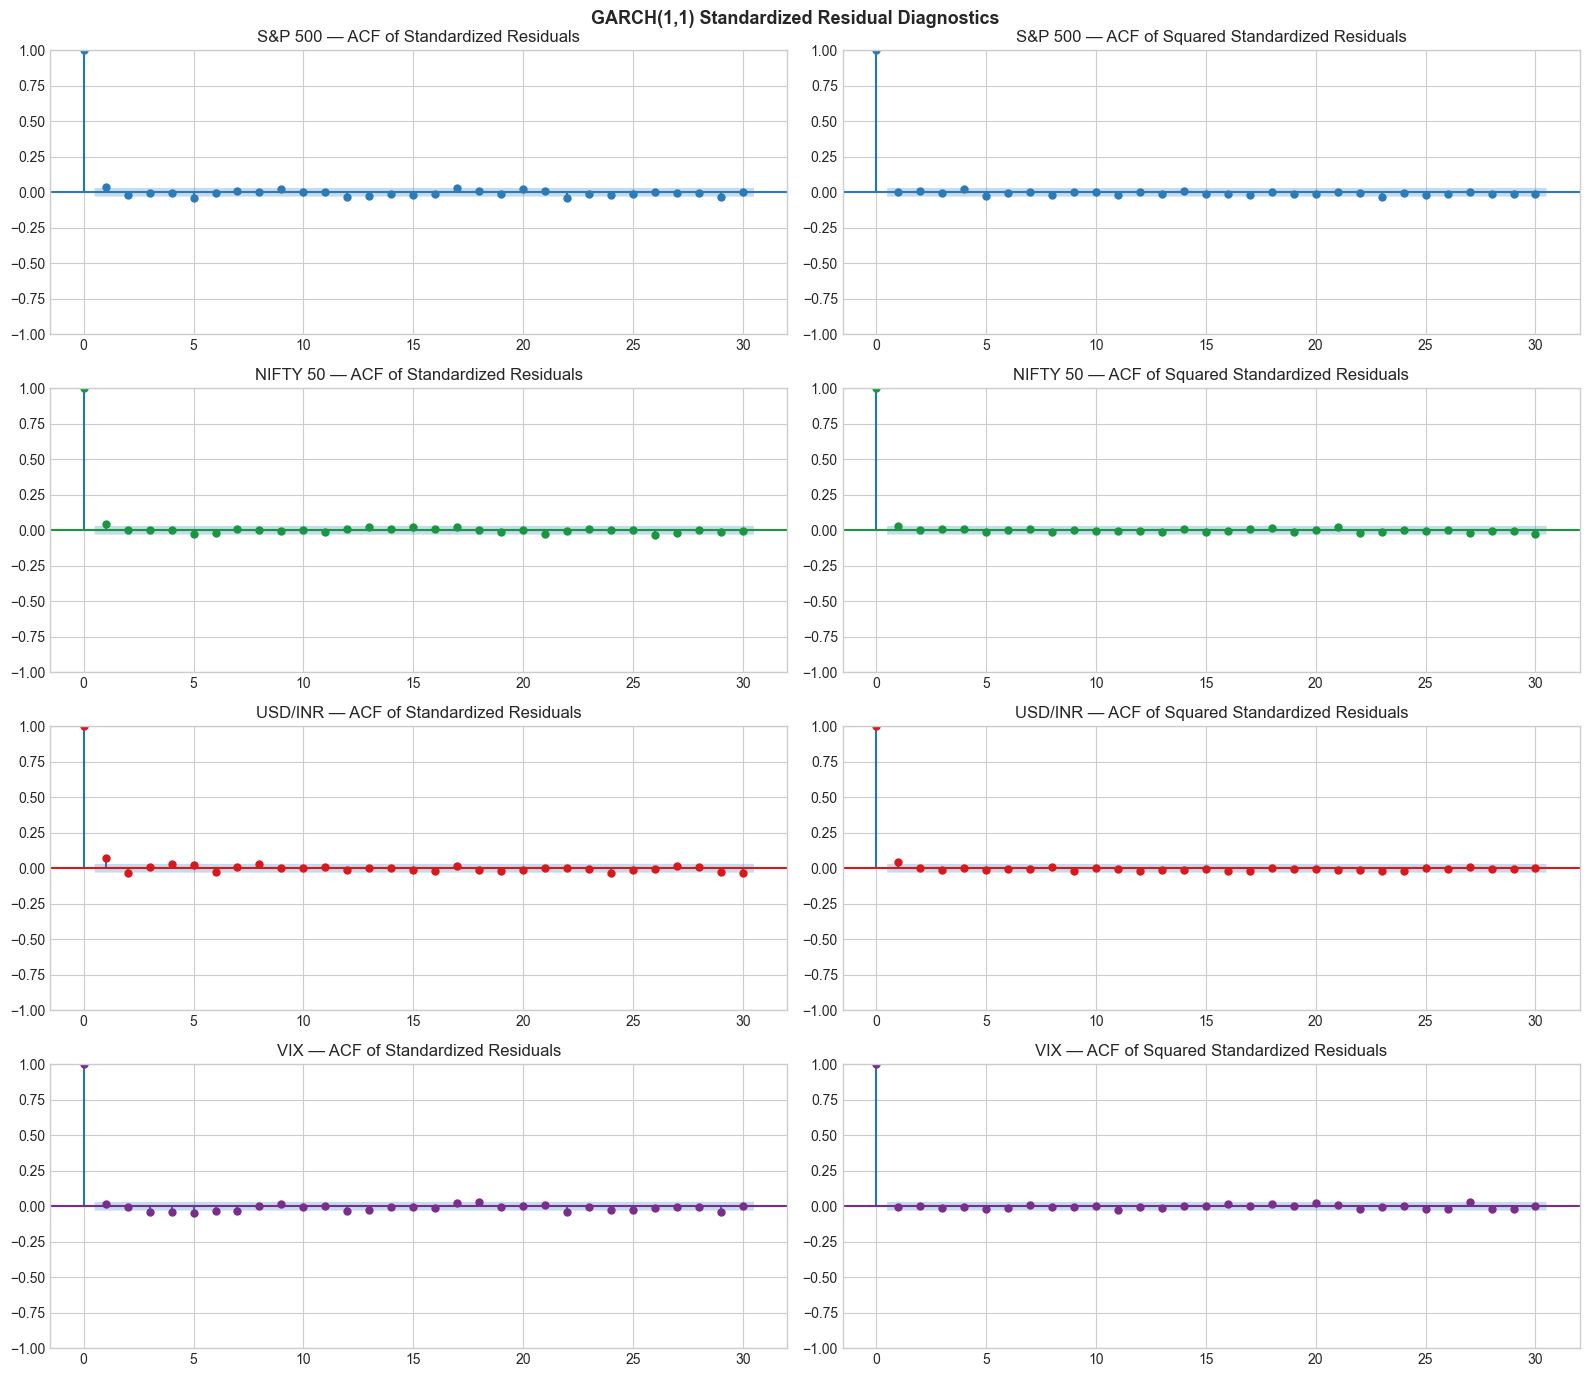

  ARCH LM TEST — GARCH STANDARDIZED RESIDUALS
Series        LM Stat    p-value               Result
------------------------------------------------------------
S&P 500        4.1650   0.525919      No ARCH effects
NIFTY 50       4.8494   0.434529      No ARCH effects
USD/INR        8.1601   0.147631      No ARCH effects
VIX            2.2686   0.810874      No ARCH effects


In [42]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))

for i, (col, color, title) in enumerate(series_info):
    std_resid = garch_results[col].std_resid

    # ACF of standardized residuals — first moment
    plot_acf(std_resid, lags=30, ax=axes[i, 0],
             color=color,
             title=f"{title} — ACF of Standardized Residuals")

    # ACF of squared standardized residuals — second moment
    plot_acf(std_resid**2, lags=30, ax=axes[i, 1],
             color=color,
             title=f"{title} — ACF of Squared Standardized Residuals")

plt.suptitle("GARCH(1,1) Standardized Residual Diagnostics",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Formal ARCH LM test on standardized residuals ─────────────
print("=" * 60)
print("  ARCH LM TEST — GARCH STANDARDIZED RESIDUALS")
print("=" * 60)
print(f"{'Series':<10} {'LM Stat':>10} {'p-value':>10} {'Result':>20}")
print("-" * 60)

for col, _, title in series_info:
    std_resid = garch_results[col].std_resid
    lm_stat, lm_pval, _, _ = het_arch(std_resid, nlags=5)
    result = "ARCH effects remain" if lm_pval < 0.05 \
             else "No ARCH effects"
    print(f"{title:<10} {lm_stat:>10.4f} {lm_pval:>10.6f} {result:>20}")

#### Final Residual Check — Interpretation

The ARCH LM test on GARCH standardized residuals fails to reject
the null of no ARCH effects for all four series — p-values range
from 0.15 to 0.81, well above the 5% threshold.

Combined with the ACF plots showing no significant autocorrelation
in either standardized residuals or their squares, we conclude that
the two-stage model has successfully extracted all signal from the data.

**The complete signal extraction pipeline:**

| Stage | Model | Extracted | Residual Check |
|-------|-------|-----------|----------------|
| 1 | VAR(2) | Mean structure | ACF of residuals — flat |
| 2 | GARCH(1,1) | Variance structure | ACF of squared residuals — flat |
| Final | — | True white noise remains | ARCH LM p > 0.05 |

This confirms:
- **First moment condition:** No autocorrelation in standardized residuals
- **Second moment condition:** No autocorrelation in squared standardized residuals

The data generating process has been fully characterized by
VAR(2) + GARCH(1,1). We now proceed to interpret the extracted
signals — what do they tell us about US-India financial integration?

----

## Stage 4 — Interpreting the Extracted Signals

Having confirmed that VAR(2) + GARCH(1,1) fully characterizes the
data generating process, we now interpret what each model tells us
about the relationship between US and Indian financial markets.

We address four questions:

1. **Granger Causality** — does SP500 predict NIFTY? Does VIX play a role?
2. **Impulse Response Functions** — how does a shock in SP500 transmit to NIFTY over time?
3. **Variance Decomposition** — what share of NIFTY's variance is explained by SP500 vs VIX?
4. **Conditional Variance** — how did volatility evolve across the sample period?

### Granger Causality

Granger causality tests whether past values of one variable contain
statistically significant information for predicting another.
We test all directional relationships in the system.

- **H0:** X does not Granger-cause Y
- Reject H0 if p-value < 0.05

In [43]:
variables = ['SP500', 'NIFTY', 'USDINR', 'VIX']
titles    = ['S&P 500', 'NIFTY 50', 'USD/INR', 'VIX']

print("=" * 70)
print("  GRANGER CAUSALITY TESTS — VAR(2)")
print("=" * 70)
print(f"{'Cause':<12} {'Effect':<12} {'F-Stat':>10} {'p-value':>10} {'Result':>20}")
print("-" * 70)

for caused, caused_title in zip(variables, titles):
    for cause, cause_title in zip(variables, titles):
        if cause != caused:
            test = var_result.test_causality(
                caused, [cause], kind='f'
            )
            result = "Granger-causes" if test.pvalue < 0.05 \
                     else "Does not cause"
            print(f"{cause_title:<12} {caused_title:<12} "
                  f"{test.test_statistic:>10.4f} "
                  f"{test.pvalue:>10.6f} {result:>20}")
    print("-" * 70)

  GRANGER CAUSALITY TESTS — VAR(2)
Cause        Effect           F-Stat    p-value               Result
----------------------------------------------------------------------
NIFTY 50     S&P 500          0.7935   0.452275       Does not cause
USD/INR      S&P 500          3.1678   0.042121       Granger-causes
VIX          S&P 500          3.8590   0.021108       Granger-causes
----------------------------------------------------------------------
S&P 500      NIFTY 50        60.3868   0.000000       Granger-causes
USD/INR      NIFTY 50         0.5896   0.554578       Does not cause
VIX          NIFTY 50         3.0855   0.045734       Granger-causes
----------------------------------------------------------------------
S&P 500      USD/INR         12.3410   0.000004       Granger-causes
NIFTY 50     USD/INR         75.1619   0.000000       Granger-causes
VIX          USD/INR         18.2104   0.000000       Granger-causes
--------------------------------------------------------------

### Granger Causality — Interpretation

**SP500 → NIFTY (F=60.39, p=0.000)**
The strongest result in the table. US equity market past returns
significantly predict Indian equity returns — confirming direct
short-run spillover from the US to India.

**NIFTY → SP500 (F=0.79, p=0.452)**
No reverse causality. The relationship is strictly unidirectional —
US leads, India follows. Consistent with a core-periphery structure
in global financial markets.

**VIX → NIFTY (F=3.09, p=0.046)**
Global fear independently predicts Indian market returns even after
controlling for SP500. This is the key addition VIX brings —
India is affected both by direct US market movements AND by
global risk sentiment separately.

**VIX → SP500 (F=3.86, p=0.021)**
VIX Granger-causes SP500, which is intuitive — rising fear
precedes market declines. This also suggests VIX carries
forward-looking information beyond what SP500 itself captures.

**SP500 → VIX (F=4.60, p=0.010)**
SP500 also Granger-causes VIX — a feedback loop exists between
US market returns and implied volatility, reflecting the
well-documented leverage effect in equity markets.

**USD/INR dynamics**
SP500, NIFTY and VIX all Granger-cause USD/INR — the exchange
rate is downstream of all three variables, absorbing shocks from
both equity markets and global risk sentiment simultaneously.
Neither USD/INR nor NIFTY Granger-cause VIX, confirming that
global fear is exogenous to Indian market conditions.

**Summary of causal structure:**
```
VIX ─────────────────────────────→ NIFTY
 ↑                                    
SP500 ──────────────────────────→ NIFTY
SP500, NIFTY, VIX ──────────────→ USD/INR
```
India is influenced by both direct US spillover and global
risk sentiment, but does not transmit shocks back to either.

### Granger Causality — Interpretation

**SP500 → NIFTY (F=60.39, p=0.000)**
The strongest result in the table. US equity market past returns
significantly predict Indian equity returns — confirming direct
short-run spillover from the US to India.

**NIFTY → SP500 (F=0.79, p=0.452)**
No reverse causality. The relationship is strictly unidirectional —
US leads, India follows. Consistent with a core-periphery structure
in global financial markets.

**VIX → NIFTY (F=3.09, p=0.046)**
Global fear independently predicts Indian market returns even after
controlling for SP500. This is the key addition VIX brings —
India is affected both by direct US market movements AND by
global risk sentiment separately.

**VIX → SP500 (F=3.86, p=0.021)**
VIX Granger-causes SP500, which is intuitive — rising fear
precedes market declines. This also suggests VIX carries
forward-looking information beyond what SP500 itself captures.

**SP500 → VIX (F=4.60, p=0.010)**
SP500 also Granger-causes VIX — a feedback loop exists between
US market returns and implied volatility, reflecting the
well-documented leverage effect in equity markets.

**USD/INR dynamics**
SP500, NIFTY and VIX all Granger-cause USD/INR — the exchange
rate is downstream of all three variables, absorbing shocks from
both equity markets and global risk sentiment simultaneously.
Neither USD/INR nor NIFTY Granger-cause VIX, confirming that
global fear is exogenous to Indian market conditions.

**Summary of causal structure:**
```
VIX ─────────────────────────────→ NIFTY
 ↑                                    
SP500 ──────────────────────────→ NIFTY
SP500, NIFTY, VIX ──────────────→ USD/INR
```
India is influenced by both direct US spillover and global
risk sentiment, but does not transmit shocks back to either.

---

### Impulse Response Functions

Granger causality established the direction of influence between
markets. Impulse Response Functions (IRFs) trace the dynamic
response of each variable to a one standard deviation shock in
another over a 15-day horizon.

This answers: given a shock in SP500 today, how does NIFTY respond
over the following two trading weeks — and how quickly does the
effect dissipate?

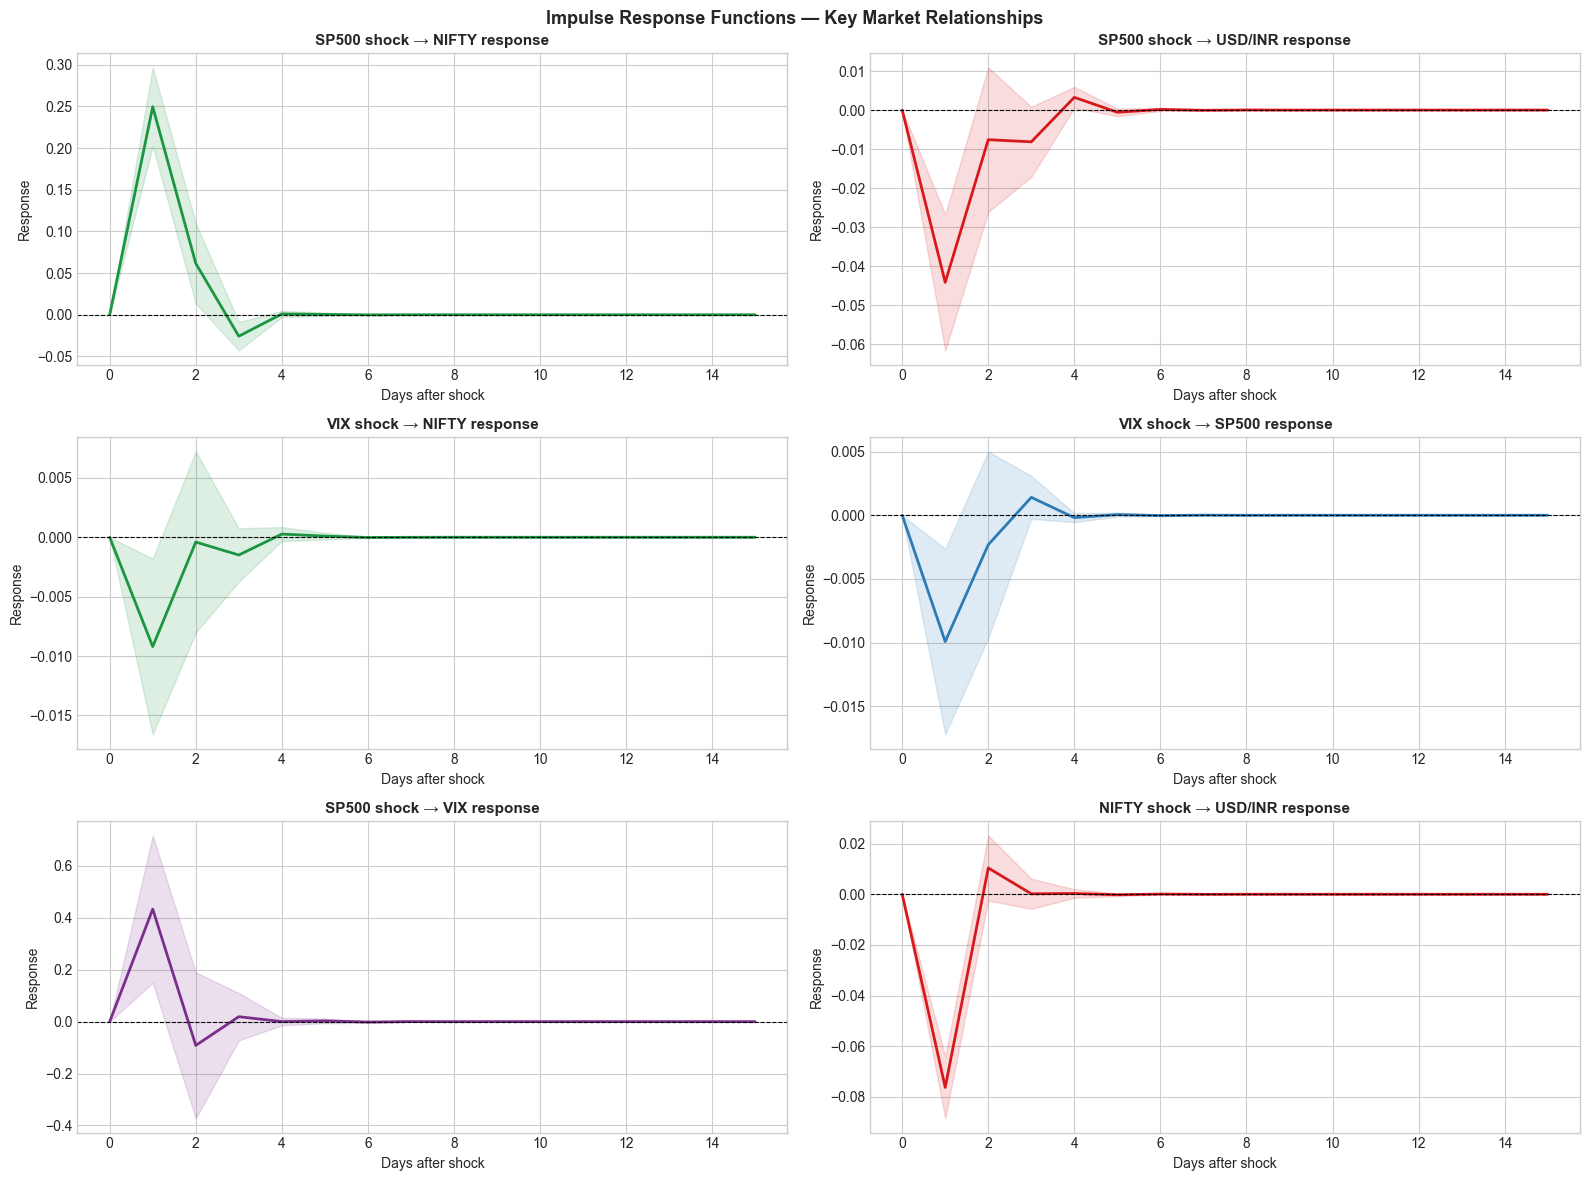

In [45]:
# ── Compute IRFs ───────────────────────────────────────────────
irf      = var_result.irf(15)
var_names = list(var_result.names)

# ── Key relationships to plot ──────────────────────────────────
pairs = [
    ("SP500",  "NIFTY",  "#1a9641", "SP500 shock → NIFTY response"),
    ("SP500",  "USDINR", "#d7191c", "SP500 shock → USD/INR response"),
    ("VIX",    "NIFTY",  "#1a9641", "VIX shock → NIFTY response"),
    ("VIX",    "SP500",  "#2c7bb6", "VIX shock → SP500 response"),
    ("SP500",  "VIX",    "#7b2d8b", "SP500 shock → VIX response"),
    ("NIFTY",  "USDINR", "#d7191c", "NIFTY shock → USD/INR response"),
]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for ax, (impulse, response, color, title) in zip(axes.flatten(), pairs):
    imp_idx  = var_names.index(impulse)
    resp_idx = var_names.index(response)

    irf_vals = irf.irfs[:, resp_idx, imp_idx]
    stderr   = irf.stderr(orth=False)[:, resp_idx, imp_idx]
    upper    = irf_vals + 1.96 * stderr
    lower    = irf_vals - 1.96 * stderr
    days     = range(len(irf_vals))

    ax.plot(days, irf_vals, color=color, linewidth=2)
    ax.fill_between(days, lower, upper, color=color, alpha=0.15)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("Days after shock")
    ax.set_ylabel("Response")

plt.suptitle("Impulse Response Functions — Key Market Relationships",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Impulse Response Functions — Interpretation

**SP500 shock → NIFTY response**
The most economically significant result. A one standard deviation
shock in SP500 produces an immediate positive response in NIFTY of
~0.25 on day 1, which dissipates completely by day 4. The effect is
sharp, short-lived, and entirely within one trading week — consistent
with modern electronic markets transmitting information rapidly across
borders. The confidence band is tight, confirming this is a
statistically robust finding.

**SP500 shock → USD/INR response**
A positive SP500 shock causes USD/INR to fall (rupee appreciates)
on day 1, reaching a trough around day 2 before recovering by day 5.
This reflects the risk-on channel — US market gains attract capital
into emerging markets, increasing demand for rupees and causing
appreciation. Effect is fully absorbed within one week.

**VIX shock → NIFTY response**
A fear spike causes NIFTY to fall (~−0.010) on day 1, recovering
by day 4. The confidence band is wide however, suggesting this
relationship is statistically weaker than the direct SP500→NIFTY
channel — consistent with VIX having a borderline Granger causality
p-value (0.046) compared to SP500's overwhelming result.

**VIX shock → SP500 response**
Rising fear causes SP500 to fall sharply on day 1 (−0.010),
recovering by day 3. The leverage effect is visible here — fear
precedes and predicts equity market declines, but the adjustment
is rapid.

**SP500 shock → VIX response**
A positive SP500 shock causes VIX to spike sharply on day 1 (~+0.45)
before falling back below zero on day 2 and returning to baseline
by day 4. The wide confidence band reflects VIX's inherently noisy
nature. The initial positive spike followed by reversal suggests
markets initially reprice uncertainty before calming.

**NIFTY shock → USD/INR response**
Strong NIFTY performance causes USD/INR to fall sharply (rupee
appreciates, ~−0.075) on day 1 then overshoots slightly positive
on day 2 before settling. This is the largest magnitude response
in the entire system — Indian equity performance has an outsized
and immediate impact on the rupee, consistent with FII flow dynamics.

**Overall pattern across all IRFs:**
All responses die out within 4−5 trading days, confirming that
while cross-market transmission is strong, it is short-lived.
Markets are informationally efficient — shocks are absorbed rapidly
and no permanent effects persist beyond one trading week.

---

### Forecast Error Variance Decomposition (FEVD)

While IRFs show how shocks transmit over time, FEVD answers a
different question — what proportion of each variable's forecast
error variance is attributable to shocks from each other variable
in the system?

In other words: how much of NIFTY's unpredictability is explained
by SP500, VIX, USD/INR, and its own past shocks respectively?

This quantifies the relative importance of each transmission channel.

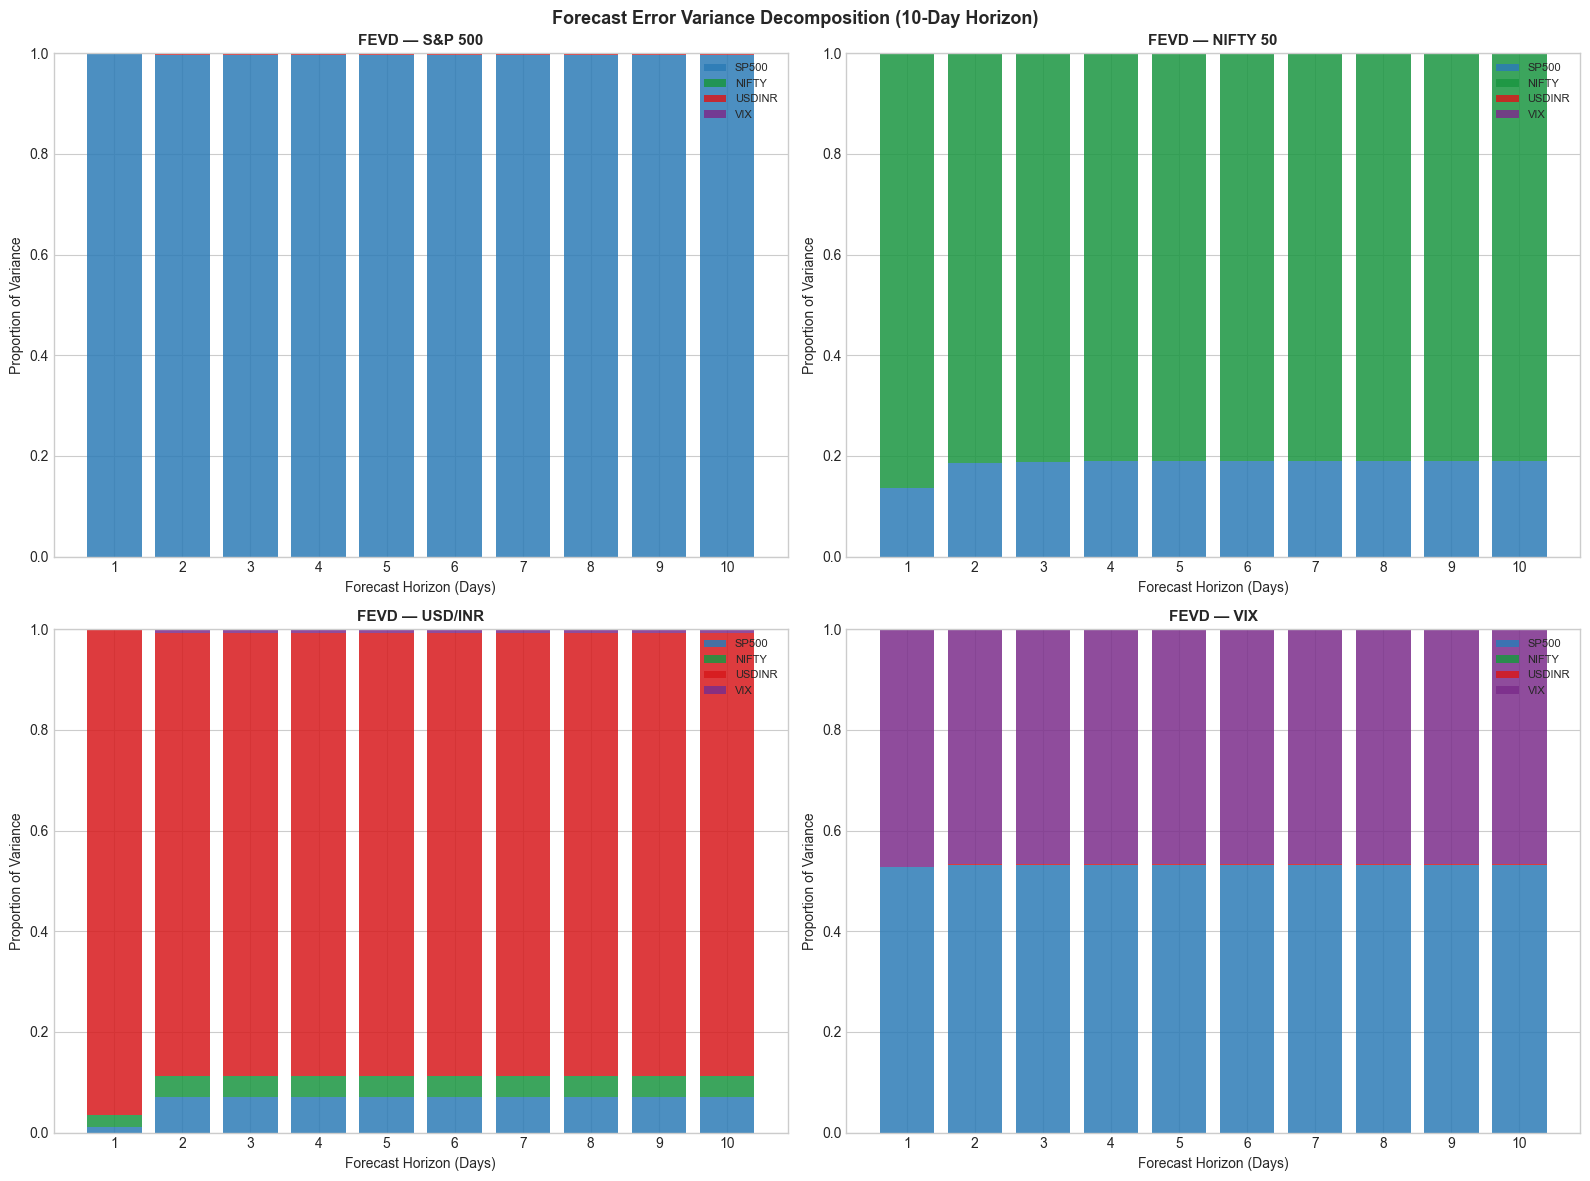

  FEVD — DAY 1 AND DAY 10 SUMMARY

Variable         SP500       NIFTY      USDINR         VIX

── Horizon: Day 1 ─────────────────────────────────────────────
S&P 500         1.0000      0.0000      0.0000      0.0000
NIFTY 50        0.1362      0.8638      0.0000      0.0000
USD/INR         0.0113      0.0241      0.9646      0.0000
VIX             0.5272      0.0003      0.0007      0.4719

── Horizon: Day 10 ─────────────────────────────────────────────
S&P 500         0.9964      0.0002      0.0016      0.0018
NIFTY 50        0.1890      0.8091      0.0005      0.0014
USD/INR         0.0714      0.0412      0.8795      0.0079
VIX             0.5312      0.0003      0.0014      0.4671


In [47]:
# ── Compute FEVD at 10-day horizon ────────────────────────────
fevd = var_result.fevd(10)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = ["#2c7bb6", "#1a9641", "#d7191c", "#7b2d8b"]

for i, (col, _, title) in enumerate(series_info):
    ax  = axes.flatten()[i]
    idx = var_names.index(col)

    # FEVD values for this variable across all 10 days
    fevd_vals = fevd.decomp[idx]   # shape (10, 4)

    # Stacked area plot
    bottom = np.zeros(10)
    days   = range(1, 11)

    for j, (src_col, color) in enumerate(zip(var_names, colors)):
        ax.bar(days, fevd_vals[:, j], bottom=bottom,
               color=color, label=src_col, alpha=0.85)
        bottom += fevd_vals[:, j]

    ax.set_title(f"FEVD — {title}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Forecast Horizon (Days)")
    ax.set_ylabel("Proportion of Variance")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_xticks(list(days))

plt.suptitle("Forecast Error Variance Decomposition (10-Day Horizon)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Print FEVD at day 1 and day 10 ────────────────────────────
print("=" * 65)
print("  FEVD — DAY 1 AND DAY 10 SUMMARY")
print("=" * 65)
print(f"\n{'Variable':<10}", end="")
for src in var_names:
    print(f"{src:>12}", end="")
print()

for horizon in [1, 10]:
    print(f"\n── Horizon: Day {horizon} {'─'*45}")
    for i, (col, _, title) in enumerate(series_info):
        idx = var_names.index(col)
        print(f"{title:<10}", end="")
        for j in range(len(var_names)):
            print(f"{fevd.decomp[idx][horizon-1, j]:>12.4f}", end="")
        print()

### Forecast Error Variance Decomposition — Interpretation

**S&P 500**
Nearly 100% of SP500's variance is explained by its own shocks
at both day 1 (100%) and day 10 (99.6%). The US market is
essentially exogenous to this system — it is not meaningfully
influenced by Indian markets, exchange rates, or even VIX at
the forecast horizons examined. This confirms SP500 as the
dominant driving variable in the system.

**NIFTY 50**
At day 1, NIFTY explains 86.4% of its own variance with SP500
contributing 13.6%. By day 10, SP500's contribution rises to
18.9% while NIFTY's own contribution falls to 80.9%. This
gradual increase in SP500's share over the forecast horizon
reflects the progressive transmission of US market information
into Indian markets — spillover strengthens over days rather
than being fully instantaneous.

VIX contributes a negligible 0.14% to NIFTY's variance at day
10, suggesting that while VIX Granger-causes NIFTY, its
quantitative contribution to NIFTY's forecast uncertainty is
small relative to direct SP500 transmission.

**USD/INR**
Own shocks dominate at day 1 (96.5%), declining to 87.9% by
day 10. SP500 and NIFTY together account for ~11% of exchange
rate variance at the 10-day horizon, confirming that both equity
markets transmit to the currency but the exchange rate retains
significant idiosyncratic dynamics — likely reflecting RBI
intervention and trade flow effects not captured by equity variables.

**VIX**
The most striking result — SP500 explains ~52% of VIX variance
at both day 1 and day 10, with VIX's own shocks accounting for
the remaining ~47%. This tight SP500-VIX relationship reflects
the well-documented leverage effect: US equity market movements
are the primary driver of implied volatility. No other variable
contributes meaningfully to VIX variance, confirming that global
fear is driven by US market dynamics, not Indian market conditions.

**Summary of key quantitative findings:**

| Variable | Own variance (Day 10) | SP500 contribution | Key channel |
|----------|-----------------------|--------------------|-------------|
| SP500 | 99.6% | — | Exogenous leader |
| NIFTY | 80.9% | 18.9% | Direct US spillover |
| USD/INR | 87.9% | 7.1% | Equity → currency |
| VIX | 46.7% | 53.1% | US market drives fear |

----

### Conditional Variance — GARCH(1,1)

The GARCH model produces a time-varying conditional variance
estimate σ²_t for each series — representing the model's estimate
of market risk at each point in time. Plotting this over the full
sample period reveals how volatility evolved across major market
events and validates the GARCH specification visually.

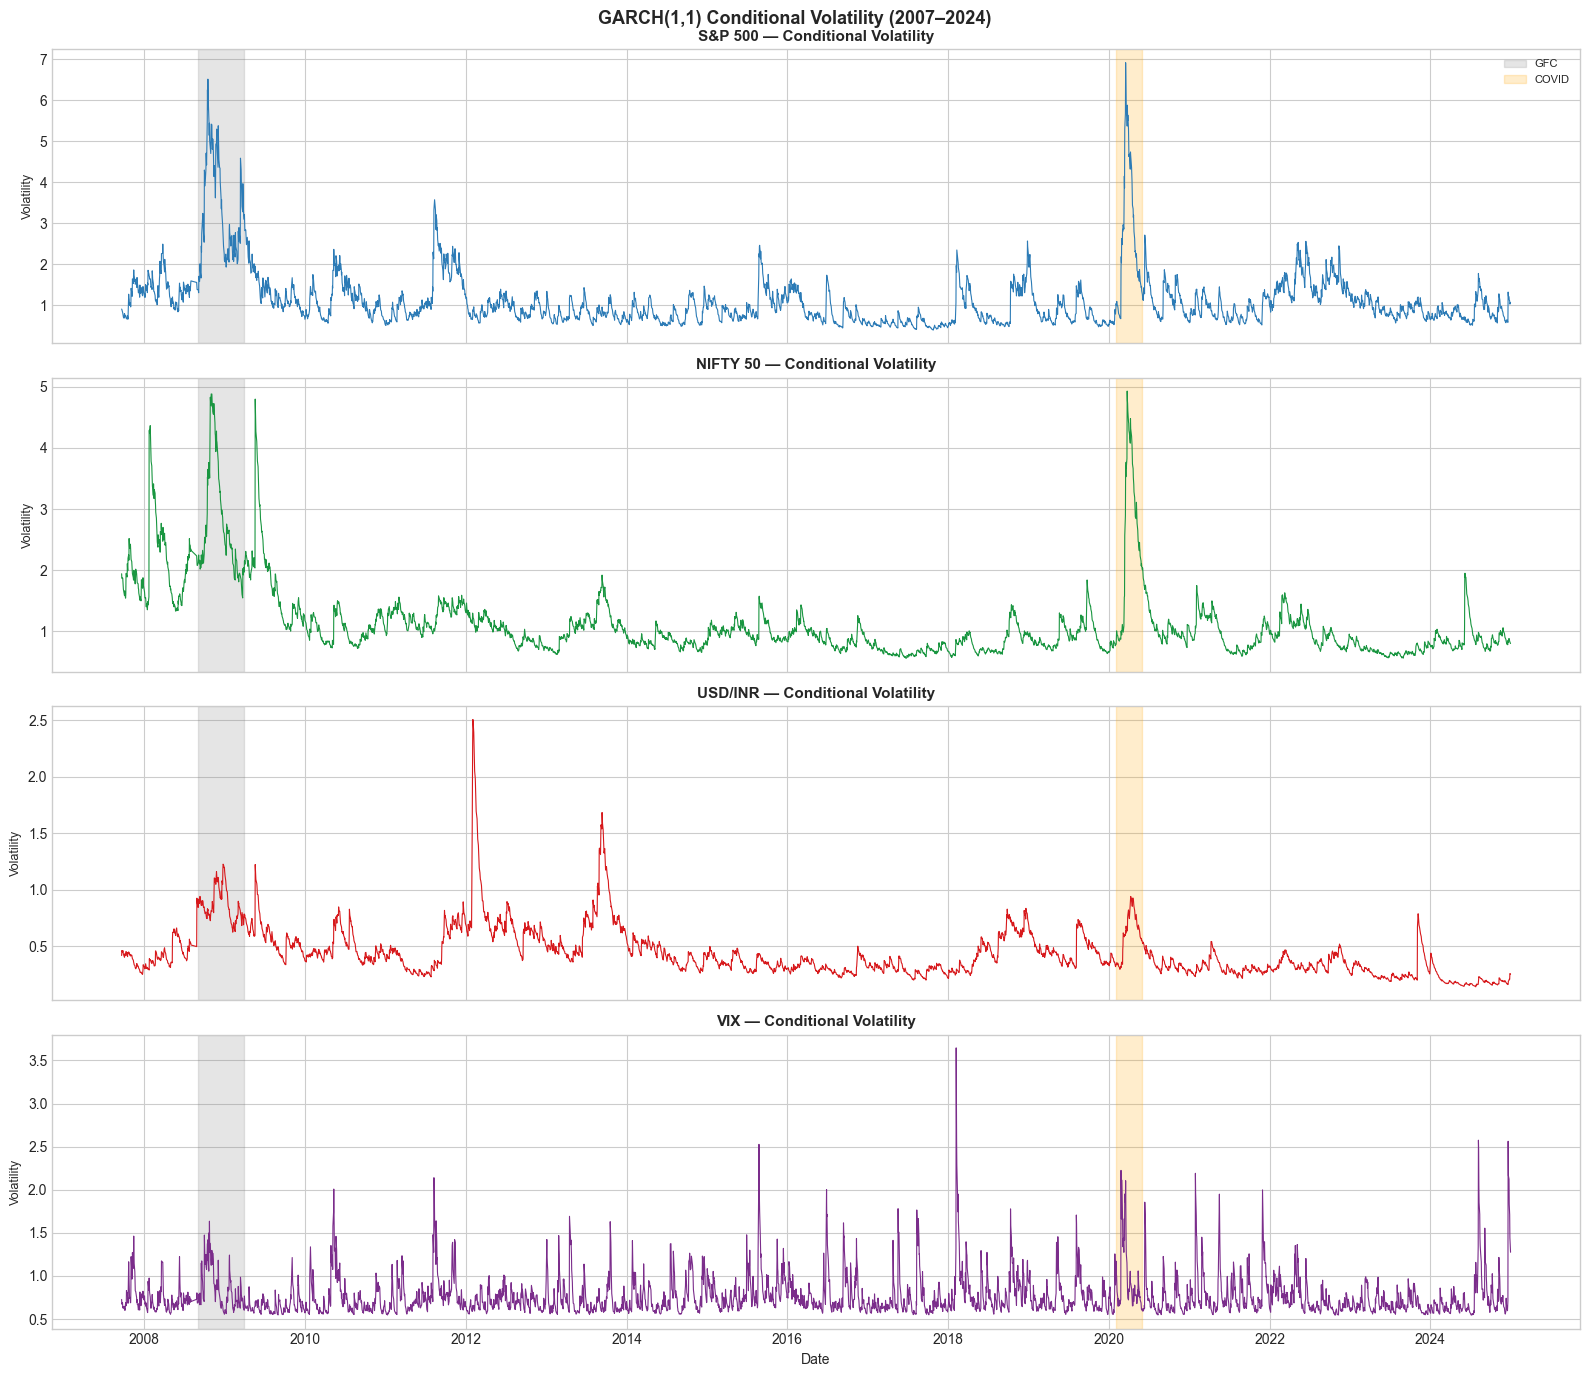

In [48]:
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

crises = [
    (pd.Timestamp("2008-09-01"), pd.Timestamp("2009-03-31"), "gray",   "GFC"),
    (pd.Timestamp("2020-02-01"), pd.Timestamp("2020-05-31"), "orange", "COVID"),
]

for i, (col, color, title) in enumerate(series_info):
    ax = axes[i]

    # Conditional volatility (annualized) = sqrt(variance) * sqrt(252)
    cond_vol = garch_results[col].conditional_volatility

    ax.plot(residuals.index, cond_vol, color=color, linewidth=0.8)
    ax.set_title(f"{title} — Conditional Volatility",
                 fontsize=11, fontweight='bold')
    ax.set_ylabel("Volatility", fontsize=9)

    for start, end, c, label in crises:
        ax.axvspan(start, end, color=c, alpha=0.2, label=label)

    if i == 0:
        ax.legend(fontsize=8)

axes[-1].set_xlabel("Date", fontsize=10)
plt.suptitle("GARCH(1,1) Conditional Volatility (2007–2024)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Conditional Volatility — Interpretation

**S&P 500**
Two dominant volatility regimes are clearly visible. The GFC
(2008-09) produced a prolonged elevated volatility period peaking
near 6.5, while COVID (2020) produced a sharper but shorter spike
reaching similar magnitude. The intervening period (2010-2019)
shows a broadly calm baseline around 1-2 with occasional spikes
— the 2011 European debt crisis and 2018 Fed tightening period
are visible as minor elevations. Post-COVID volatility has
normalized rapidly, consistent with the high β (0.85) but also
the swift policy response by central banks.

**NIFTY 50**
Conditional volatility pattern broadly mirrors SP500 — GFC and
COVID spikes are clearly synchronized, visually confirming the
spillover relationship quantified in Granger and IRF analysis.
Notably NIFTY showed elevated volatility even before the formal
GFC period (2007-08), reflecting India's own domestic bull market
turbulence. Post-2010 volatility settled at lower levels than the
US, consistent with NIFTY's high β (0.92) — once calm, Indian
markets stay calm for extended periods.

**USD/INR**
The exchange rate tells a distinctly different story. The largest
volatility spike occurs in 2012-13 — the period of the Taper
Tantrum and INR depreciation crisis — rather than during GFC or
COVID. This reflects RBI's active intervention during the 2008
crisis which suppressed exchange rate volatility, while the 2013
capital outflow episode caught the central bank less prepared.
Post-2020 volatility has declined to historically low levels,
suggesting increased RBI effectiveness in managing exchange rate
stability in recent years.

**VIX**
Unlike the other three series, VIX conditional volatility does
not show the same GFC dominance. Instead it displays persistent
high-frequency spikes throughout the entire sample — consistent
with VIX's nature as a forward-looking fear gauge that reacts to
every market uncertainty episode rather than just major crises.
The 2018 spike is prominent — the VIX volatility spike of
February 2018 (the "Volmageddon" event) is clearly captured.
The lower α+β (0.87) relative to other series is visually
confirmed — VIX volatility spikes are sharper but mean-revert
faster than equity volatility.

**Cross-series observation**
SP500 and NIFTY volatility spikes are visually synchronized
during GFC and COVID, while USD/INR and VIX show more
idiosyncratic patterns. This reinforces the core finding —
equity market integration between US and India is strong,
but the transmission mechanism through currency and fear
channels operates on different timescales and drivers.